In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat_stack = []

for field in ['south', 'north']:
    cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_{}_1.0.0_basic.fits'.format(field)))
    cat_wisemask = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_{}_1.0.0_wisemask.fits'.format(field)))
    cat_pz = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_{}_1.0.0_pz_new.fits'.format(field)))
    wmask = np.load('/global/cfs/cdirs/desi/users/rongpu/data/imaging_sys/bright_star_masks/dev/dr9_lrg_{}_1.0.0_basic-wisemask.npz'.format(field))
    gmask = np.load('/global/cfs/cdirs/desi/users/rongpu/data/imaging_sys/bright_star_masks/dev/dr9_lrg_{}_1.0.0_basic-gaiamask.npz'.format(field))

    cat = hstack([cat, cat_wisemask, cat_pz], join_type='exact')
    cat['wise_mask'] = wmask['wise_mask']
    cat['gaia_mask'] = gmask['gaia_mask']
    cat['gaia_bright_mask'] = gmask['gaia_bright_mask']
    
    cat_stack.append(cat)
    
cat = vstack(cat_stack)
print(len(cat))

12338990


In [4]:
# New mask

apply_unwise_spike = True
if apply_unwise_spike:
    wise_maskbits = [0, 1, 2, 3, 4, 6, 7]  # all except the HALO bit
else:
    wise_maskbits = [0, 2, 3, 4, 6, 7]  # all except the SPIKE and HALO bits

# Apply the unWISE maskbits
mask_unwise = np.zeros(len(cat), dtype=bool)
for bit in wise_maskbits:
    mask_unwise |= (cat['WISEMASK_W1'] & 2**bit)>0

wise_mask = cat['wise_mask'] | mask_unwise

new_mask = wise_mask | cat['gaia_mask']
mask_clean = ~(new_mask)

print(np.sum(mask_clean)/len(mask_clean))

cat = cat[mask_clean]
print(len(cat))

0.8767090337215607
10817704


In [5]:
from sklearn.cluster import DBSCAN

In [6]:
ra, dec = cat['RA'], cat['DEC']

# Convert (RA, Dec) to unit vector in cartesian coordinates
x = np.cos(ra/180*np.pi)*np.cos(dec/180*np.pi)
y = np.sin(ra/180*np.pi)*np.cos(dec/180*np.pi)
z = np.sin(dec/180*np.pi)
X = np.column_stack([x, y, z])

In [7]:
# Compute DBSCAN
db = DBSCAN(eps=np.radians(1./60.), min_samples=10, n_jobs=6).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
all_samples_mask = labels>=0

# Number of clusters in labels, ignoring noise if present.
# n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_clusters = len(np.unique(db.labels_[db.labels_!=-1]))

print('Estimated number of clusters: %d' % n_clusters)
print('Fraction of objects in clusters: {:.2f}%'.format(np.sum(core_samples_mask)/len(X)*100))

Estimated number of clusters: 280
Fraction of objects in clusters: 0.01%


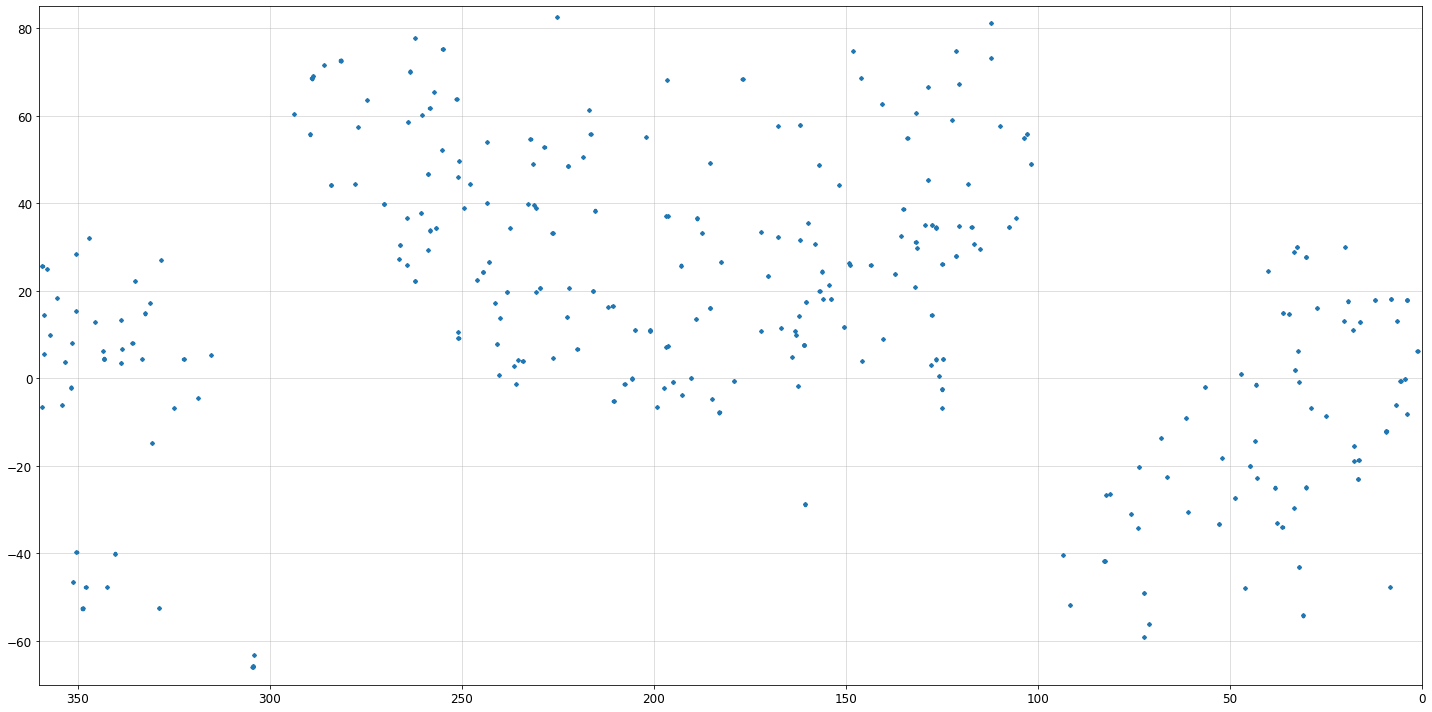

In [8]:
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(1, 1, 1)
ax.plot(ra[all_samples_mask], dec[all_samples_mask], '.', ms=5, alpha=1)
plt.axis([360, 0, -70, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/Downloads/corrupt/g_cluster.png')
plt.show()

In [10]:
t = Table()
t['label'], t['counts'] = np.unique(labels, return_counts=True)
mask = t['label']!=-1
t = t[mask]
t['ra'] = 0.
t['dec'] = 0.

for index in range(len(t)):
    label = t['label'][index]
    mask = labels==label
    t['ra'][index] = np.mean(ra[mask])
    t['dec'][index] = np.mean(dec[mask])
    
t.write('/Users/rongpu/Downloads/visual_inspection_dbscan.fits', overwrite=True)
t[['ra', 'dec']].write('/Users/rongpu/Downloads/visual_inspection_dbscan.txt', format='ascii.no_header', overwrite=True)

In [11]:
t

label,counts,ra,dec
int64,int64,float64,float64
0,24,343.1473738067021,4.532502860386938
1,10,33.184475868093976,-29.583919040954004
2,10,38.28137015268485,-24.927970542358118
3,12,30.06391980941085,-24.919721632554026
4,12,56.5603825743911,-2.002191179087985
5,10,240.32796163388306,0.7855797795015719
6,10,51.94430199407064,-18.1134102747312
7,14,194.93598993964727,-0.7752452255166838
8,11,197.36573540742856,-2.239144205557836


-------

In [12]:
min_nobs = 2
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]

In [13]:
outliers = ((cat['Z_PHOT_STD']/(1+cat['Z_PHOT_MEDIAN']))>0.06)
print(np.sum(outliers), np.sum(outliers)/len(cat)*100, '%')

564403 5.445298915316501 %


In [14]:
fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][outliers], np.sin(np.radians(cat['DEC'][outliers])), '.', ms=2, alpha=0.5)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/Downloads/lrg_radec/lrg_pz_outliers1.png')
plt.close()

In [15]:
ra, dec = cat['RA'][outliers], cat['DEC'][outliers]

# Convert (RA, Dec) to unit vector in cartesian coordinates
x = np.cos(ra/180*np.pi)*np.cos(dec/180*np.pi)
y = np.sin(ra/180*np.pi)*np.cos(dec/180*np.pi)
z = np.sin(dec/180*np.pi)
X = np.column_stack([x, y, z])

In [16]:
# Compute DBSCAN
db = DBSCAN(eps=np.radians(0.3), min_samples=30, n_jobs=6).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
all_samples_mask = labels>=0

# Number of clusters in labels, ignoring noise if present.
# n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_clusters = len(np.unique(db.labels_[db.labels_!=-1]))

print('Estimated number of clusters: %d' % n_clusters)
print('Fraction of objects in clusters: {:.2f}%'.format(np.sum(core_samples_mask)/len(X)*100))

Estimated number of clusters: 45
Fraction of objects in clusters: 0.16%


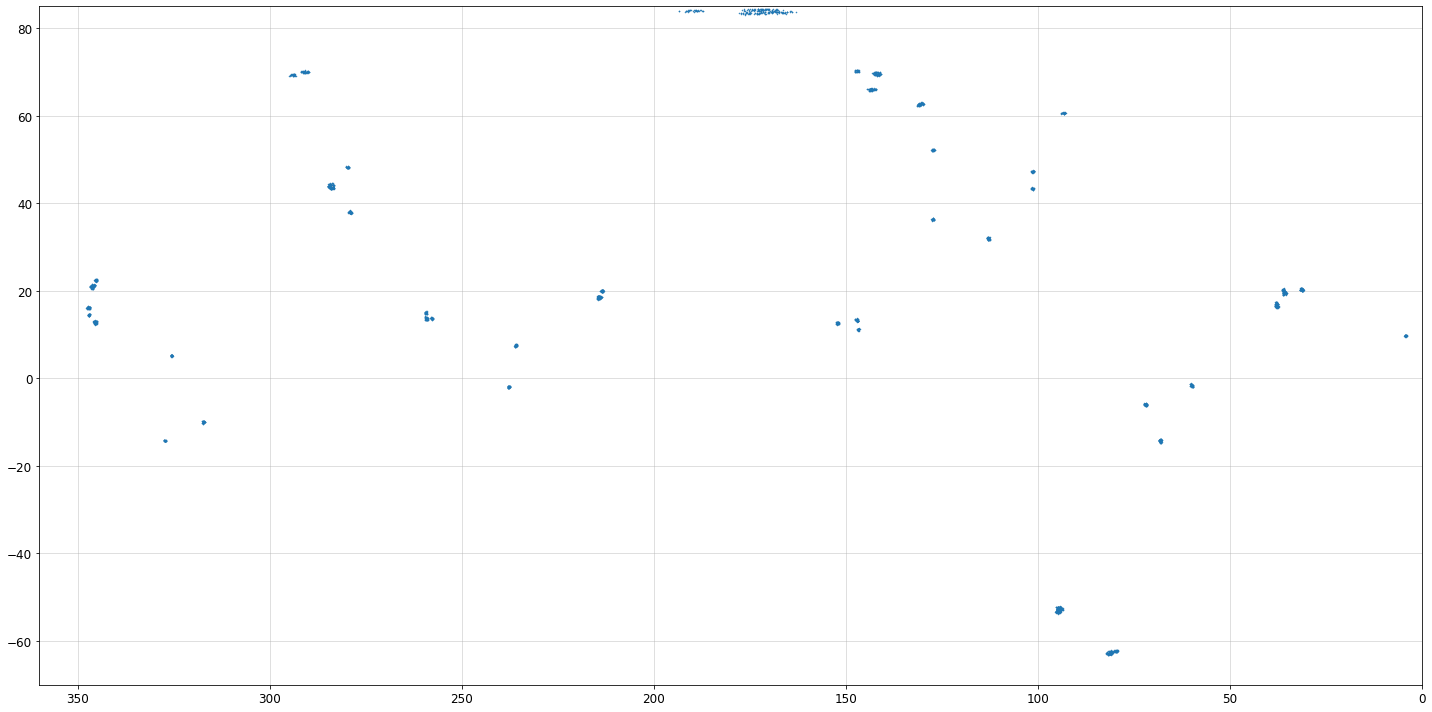

In [17]:
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(1, 1, 1)
ax.plot(ra[all_samples_mask], dec[all_samples_mask], '.', ms=1, alpha=1)
plt.axis([360, 0, -70, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/Downloads/corrupt/g_cluster.png')
plt.show()

In [18]:
t = Table()
t['label'], t['counts'] = np.unique(labels, return_counts=True)
mask = t['label']!=-1
t = t[mask]
t['ra'] = 0.
t['dec'] = 0.

for index in range(len(t)):
    label = t['label'][index]
    mask = labels==label
    t['ra'][index] = np.mean(ra[mask])
    t['dec'][index] = np.mean(dec[mask])
    
t.write('/Users/rongpu/Downloads/visual_inspection_dbscan_pz.fits', overwrite=True)
t[['ra', 'dec']].write('/Users/rongpu/Downloads/visual_inspection_dbscan_pz.txt', format='ascii.no_header', overwrite=True)

In [19]:
t

label,counts,ra,dec
int64,int64,float64,float64
0,61,71.91401922222067,-5.975212456059456
1,54,347.2497999434999,16.180109787407076
2,34,347.12949335017754,14.514410653534206
3,82,345.4849587464811,12.81447730027404
4,55,59.899905117826236,-1.5922708108519108
5,37,146.77611226977828,11.16506061306514
6,54,147.0994031798971,13.368210742456325
7,30,79.61263695091571,-62.31625221885732
8,73,81.25882026554741,-62.721994360089376
